In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

print(f"MediaPipe version: {mp.__version__}")
print(f"OpenCV version: {cv2.__version__}")

MediaPipe version: 0.10.35
OpenCV version: 4.13.0


In [12]:
# Ruta al modelo descargado
MODEL_PATH = "/home/fabian/AIronVision/ml/models/pose_landmarker_heavy.task"

# Configuración del detector
base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,  # IMAGE para fotos, VIDEO para videos
    num_poses=1,                            # Solo detectar 1 persona
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False,
)

detector = vision.PoseLandmarker.create_from_options(options)
print("Detector creado correctamente ✅")

Detector creado correctamente ✅


I0000 00:00:1777526142.547834   12694 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777526142.549612   12724 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.6), renderer: AMD Radeon 890M Graphics (radeonsi, gfx1150, LLVM 21.1.8, DRM 3.64, 6.19.14-200.fc43.x86_64)
W0000 00:00:1777526142.573070   12697 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777526142.603434   12708 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Forma de la imagen: (800, 800, 3)


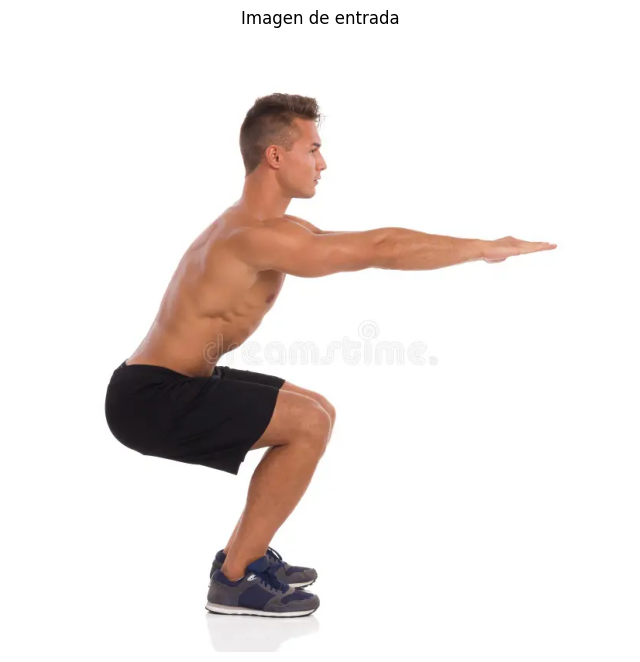

In [13]:
IMAGE_PATH = "/home/fabian/AIronVision/ml/data/test_squat.jpg"

# Cargamos con OpenCV (BGR) y convertimos a RGB que es lo que MediaPipe espera
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Forma de la imagen: {image_rgb.shape}")  # (alto, ancho, canales)

# Visualizamos
plt.figure(figsize=(8, 10))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('Imagen de entrada')
plt.show()

In [14]:
# Convertir a formato MediaPipe Image
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

# Detectar
result = detector.detect(mp_image)

# ¿Detectó alguna pose?
if result.pose_landmarks:
    print(f"✅ Detectó {len(result.pose_landmarks)} pose(s)")
    print(f"Total de landmarks: {len(result.pose_landmarks[0])}")
else:
    print("❌ No detectó ninguna pose. Revisa la imagen.")

✅ Detectó 1 pose(s)
Total de landmarks: 33


W0000 00:00:1777526209.200060   12705 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [20]:
import numpy as np
from mediapipe.framework.formats import landmark_pb2
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles


def draw_landmarks_on_image(rgb_image, detection_result):
    """
    Dibuja los landmarks y conexiones del esqueleto sobre la imagen.
    
    Nota técnica: drawing_utils.draw_landmarks() espera un protobuf
    NormalizedLandmarkList, no la lista plana que devuelve el detector.
    Por eso convertimos antes de dibujar.
    """
    annotated_image = np.copy(rgb_image)

    if not detection_result.pose_landmarks:
        return annotated_image

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(
        color=(0, 255, 0),
        thickness=2,
    )

    for pose_landmarks in detection_result.pose_landmarks:
        # Convertir lista plana -> protobuf que drawing_utils entiende
        pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        pose_landmarks_proto.landmark.extend([
            landmark_pb2.NormalizedLandmark(
                x=lm.x,
                y=lm.y,
                z=lm.z,
                visibility=lm.visibility,
                presence=lm.presence,
            )
            for lm in pose_landmarks
        ])

        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks_proto,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style,
        )

    return annotated_image


annotated_image = draw_landmarks_on_image(image_rgb, result)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 10))
plt.imshow(annotated_image)
plt.axis('off')
plt.title('Pose detectada')
plt.show()

ModuleNotFoundError: No module named 'mediapipe.framework'

In [22]:
import mediapipe as mp
print(f"MediaPipe version: {mp.__version__}")
print(f"Python version: {__import__('sys').version}")

import mediapipe as mp
import pkgutil

# Top-level de mediapipe
print("=== mediapipe submodules ===")
for m in pkgutil.iter_modules(mp.__path__):
    print(f"  {m.name}")

# ¿Existe tasks?
from mediapipe import tasks
import pkgutil
print("=== mediapipe.tasks submodules ===")
for m in pkgutil.iter_modules(tasks.__path__):
    print(f"  {m.name}")

    # ¿Existe vision dentro de tasks.python?
from mediapipe.tasks import python as mp_python
import pkgutil
print("=== mediapipe.tasks.python submodules ===")
for m in pkgutil.iter_modules(mp_python.__path__):
    print(f"  {m.name}")

# ¿Qué hay en vision?
from mediapipe.tasks.python import vision
print("=== mediapipe.tasks.python.vision contents ===")
items = [x for x in dir(vision) if not x.startswith('_')]
for item in items:
    print(f"  {item}")

# Buscar dónde vive landmark_pb2
import mediapipe
import os
for root, dirs, files in os.walk(os.path.dirname(mediapipe.__file__)):
    for f in files:
        if 'landmark_pb2' in f:
            print(os.path.join(root, f))

MediaPipe version: 0.10.35
Python version: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
=== mediapipe submodules ===
  tasks
=== mediapipe.tasks submodules ===
  audio
  benchmark
  components
  core
  genai
  metadata
  test
  text
  vision
=== mediapipe.tasks.python submodules ===
  audio
  benchmark
  components
  core
  genai
  metadata
  test
  text
  vision
=== mediapipe.tasks.python.vision contents ===
  FaceDetector
  FaceDetectorOptions
  FaceDetectorResult
  FaceLandmarker
  FaceLandmarkerOptions
  FaceLandmarkerResult
  FaceLandmarksConnections
  GestureRecognizer
  GestureRecognizerOptions
  GestureRecognizerResult
  HandLandmarker
  HandLandmarkerOptions
  HandLandmarkerResult
  HandLandmarksConnections
  HolisticLandmarker
  HolisticLandmarkerOptions
  HolisticLandmarkerResult
  ImageClassifier
  ImageClassifierOptions
  ImageClassifierResult
  ImageEmbedder
  ImageEmbedderOptions
  ImageEmbedderResult
  ImageProcessingOptions
  ImageSegm

In [23]:
from mediapipe.tasks.python.vision import drawing_utils
import inspect

# Ver la firma de la función
print("=== Firma de draw_landmarks ===")
print(inspect.signature(drawing_utils.draw_landmarks))
print()

# Ver el docstring
print("=== Docstring ===")
print(inspect.getdoc(drawing_utils.draw_landmarks))
print()

# Ver qué tipos espera (si están anotados)
print("=== Source de las primeras líneas ===")
try:
    source = inspect.getsource(drawing_utils.draw_landmarks)
    # Solo las primeras 30 líneas para no saturar
    print('\n'.join(source.split('\n')[:30]))
except Exception as e:
    print(f"No se pudo obtener: {e}")

=== Firma de draw_landmarks ===
(image: numpy.ndarray, landmark_list: list[mediapipe.tasks.python.components.containers.landmark.NormalizedLandmark], connections: Optional[list[mediapipe.tasks.python.vision.face_landmarker.FaceLandmarksConnections.Connection]] = None, landmark_drawing_spec: Union[mediapipe.tasks.python.vision.drawing_utils.DrawingSpec, Mapping[int, mediapipe.tasks.python.vision.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2), connection_drawing_spec: Union[mediapipe.tasks.python.vision.drawing_utils.DrawingSpec, Mapping[tuple[int, int], mediapipe.tasks.python.vision.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2), is_drawing_landmarks: bool = True)

=== Docstring ===
Draws the landmarks and the connections on the image.

Args:
  image: A three channel BGR image represented as numpy ndarray.
  landmark_list: A list of normalized landmarks to be annotated on the image.
  c

In [24]:
from mediapipe.tasks.python.vision import PoseLandmarksConnections

print("=== Atributos de PoseLandmarksConnections ===")
print([x for x in dir(PoseLandmarksConnections) if not x.startswith('_')])
print()

# Ver qué es POSE_LANDMARKS si existe
if hasattr(PoseLandmarksConnections, 'POSE_LANDMARKS'):
    pl = PoseLandmarksConnections.POSE_LANDMARKS
    print(f"Tipo: {type(pl)}")
    print(f"Primeros 3 elementos: {list(pl)[:3] if hasattr(pl, '__iter__') else pl}")

=== Atributos de PoseLandmarksConnections ===
['Connection', 'POSE_LANDMARKS']

Tipo: <class 'list'>
Primeros 3 elementos: [PoseLandmarksConnections.Connection(start=0, end=1), PoseLandmarksConnections.Connection(start=1, end=2), PoseLandmarksConnections.Connection(start=2, end=3)]


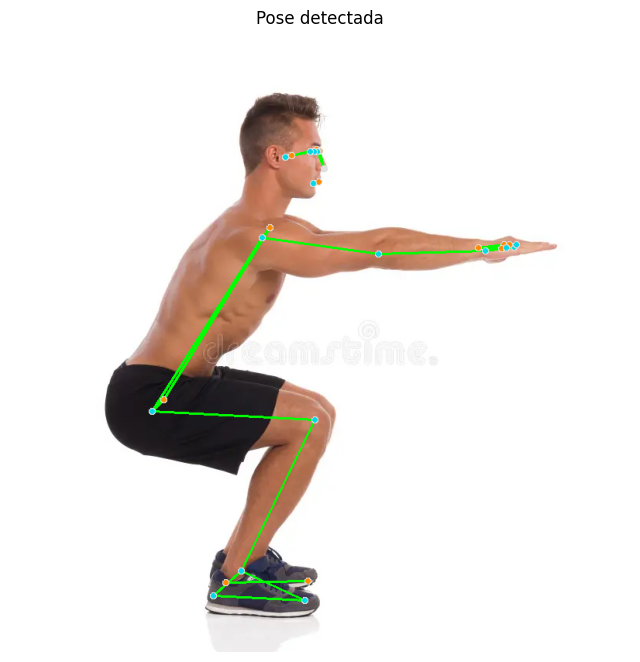

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks.python.vision import (
    PoseLandmarksConnections,
    drawing_utils,
    drawing_styles,
)


def draw_pose_on_image(rgb_image: np.ndarray, detection_result) -> np.ndarray:
    """
    Dibuja los landmarks y conexiones del esqueleto sobre una imagen.

    Args:
        rgb_image: Imagen en formato RGB (numpy array).
        detection_result: Salida de PoseLandmarker.detect().

    Returns:
        Imagen RGB con el esqueleto dibujado, lista para matplotlib.

    Nota: drawing_utils.draw_landmarks espera la imagen en BGR (formato
    nativo de OpenCV). Convertimos antes y después de dibujar para
    mantener la consistencia con el resto del notebook que trabaja en RGB.
    """
    if not detection_result.pose_landmarks:
        return np.copy(rgb_image)

    # RGB -> BGR para el dibujado
    bgr_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)
    annotated_bgr = np.copy(bgr_image)

    # Estilos
    landmark_style = drawing_styles.get_default_pose_landmarks_style()
    connection_style = drawing_utils.DrawingSpec(
        color=(0, 255, 0),  # verde en BGR (también en RGB para verde puro)
        thickness=2,
    )

    # Una imagen puede tener múltiples personas detectadas; iteramos por todas
    for pose_landmarks in detection_result.pose_landmarks:
        drawing_utils.draw_landmarks(
            image=annotated_bgr,
            landmark_list=pose_landmarks,
            connections=PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=landmark_style,
            connection_drawing_spec=connection_style,
        )

    # BGR -> RGB para devolver listo para matplotlib
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    return annotated_rgb


# Ejecutar y visualizar
annotated_image = draw_pose_on_image(image_rgb, result)

plt.figure(figsize=(8, 10))
plt.imshow(annotated_image)
plt.axis('off')
plt.title('Pose detectada')
plt.show()

In [31]:
# MediaPipe usa una convención de 33 landmarks
LANDMARK_NAMES = {
    0: "nose", 11: "left_shoulder", 12: "right_shoulder",
    13: "left_elbow", 14: "right_elbow",
    15: "left_wrist", 16: "right_wrist",
    23: "left_hip", 24: "right_hip",
    25: "left_knee", 26: "right_knee",
    27: "left_ankle", 28: "right_ankle",
}

landmarks = result.pose_landmarks[0]
print("Landmarks clave para sentadilla:\n")
print(f"{'Nombre':<18} {'X':>8} {'Y':>8} {'Z':>8} {'Visibility':>12}")
print("-" * 56)
for idx, name in LANDMARK_NAMES.items():
    lm = landmarks[idx]
    print(f"{name:<18} {lm.x:>8.3f} {lm.y:>8.3f} {lm.z:>8.3f} {lm.visibility:>12.3f}")

Landmarks clave para sentadilla:

Nombre                    X        Y        Z   Visibility
--------------------------------------------------------
nose                  0.507    0.221   -0.070        1.000
left_shoulder         0.419    0.315    0.251        1.000
right_shoulder        0.407    0.332   -0.363        1.000
left_elbow            0.594    0.336    0.289        0.401
right_elbow           0.595    0.358   -0.515        0.986
left_wrist            0.756    0.349    0.158        0.553
right_wrist           0.767    0.353   -0.498        0.977
left_hip              0.248    0.593    0.204        1.000
right_hip             0.229    0.612   -0.204        1.000
left_knee             0.475    0.615    0.311        0.161
right_knee            0.492    0.625   -0.224        0.986
left_ankle            0.388    0.843    0.463        0.479
right_ankle           0.373    0.869   -0.042        0.991


In [32]:
import numpy as np
from enum import IntEnum


class PoseLandmark(IntEnum):
    """Índices de los 33 landmarks de MediaPipe Pose."""
    NOSE = 0
    LEFT_SHOULDER = 11
    RIGHT_SHOULDER = 12
    LEFT_ELBOW = 13
    RIGHT_ELBOW = 14
    LEFT_WRIST = 15
    RIGHT_WRIST = 16
    LEFT_HIP = 23
    RIGHT_HIP = 24
    LEFT_KNEE = 25
    RIGHT_KNEE = 26
    LEFT_ANKLE = 27
    RIGHT_ANKLE = 28


def calculate_angle_2d(point_a, point_b, point_c) -> float:
    """
    Calcula el ángulo formado por tres puntos en 2D, con vértice en B.

    Args:
        point_a: Tupla (x, y) o landmark con .x .y
        point_b: Vértice del ángulo
        point_c: Tercer punto

    Returns:
        Ángulo en grados entre 0 y 180.

    Ejemplo: para ángulo de rodilla, A=cadera, B=rodilla, C=tobillo.
    """
    # Convertir a arrays numpy (acepta tanto landmarks como tuplas)
    a = np.array([point_a.x, point_a.y]) if hasattr(point_a, 'x') else np.array(point_a)
    b = np.array([point_b.x, point_b.y]) if hasattr(point_b, 'x') else np.array(point_b)
    c = np.array([point_c.x, point_c.y]) if hasattr(point_c, 'x') else np.array(point_c)

    # Vectores desde el vértice B
    ba = a - b
    bc = c - b

    # Producto punto y magnitudes
    dot_product = np.dot(ba, bc)
    magnitude_ba = np.linalg.norm(ba)
    magnitude_bc = np.linalg.norm(bc)

    # Evitar división por cero (puntos solapados)
    if magnitude_ba == 0 or magnitude_bc == 0:
        return 0.0

    # arccos del producto punto normalizado, clamp por estabilidad numérica
    cosine = np.clip(dot_product / (magnitude_ba * magnitude_bc), -1.0, 1.0)
    angle_radians = np.arccos(cosine)

    return float(np.degrees(angle_radians))


# Aplicarlo a la imagen de prueba
landmarks = result.pose_landmarks[0]

left_hip = landmarks[PoseLandmark.LEFT_HIP]
left_knee = landmarks[PoseLandmark.LEFT_KNEE]
left_ankle = landmarks[PoseLandmark.LEFT_ANKLE]

knee_angle = calculate_angle_2d(left_hip, left_knee, left_ankle)

print(f"📐 Ángulo de rodilla izquierda: {knee_angle:.1f}°")
print(f"   Visibility cadera:  {left_hip.visibility:.2f}")
print(f"   Visibility rodilla: {left_knee.visibility:.2f}")
print(f"   Visibility tobillo: {left_ankle.visibility:.2f}")

📐 Ángulo de rodilla izquierda: 74.4°
   Visibility cadera:  1.00
   Visibility rodilla: 0.16
   Visibility tobillo: 0.48


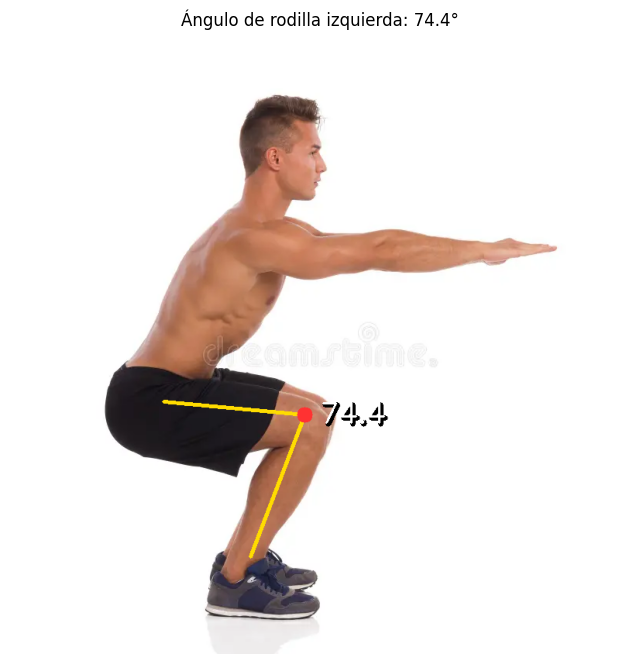

In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def draw_angle_on_image(rgb_image, point_a, point_b, point_c, angle_value: float):
    """
    Dibuja un ángulo (con arco y valor) sobre la imagen.

    Args:
        rgb_image: Imagen RGB.
        point_a, point_b, point_c: landmarks normalizados (0-1) de MediaPipe.
        angle_value: Valor del ángulo en grados ya calculado.
    """
    annotated = np.copy(rgb_image)
    h, w = annotated.shape[:2]

    # Convertir coordenadas normalizadas (0-1) a píxeles
    a_px = (int(point_a.x * w), int(point_a.y * h))
    b_px = (int(point_b.x * w), int(point_b.y * h))
    c_px = (int(point_c.x * w), int(point_c.y * h))

    # Línea cadera-rodilla y rodilla-tobillo en amarillo grueso
    cv2.line(annotated, a_px, b_px, (255, 220, 0), 4)
    cv2.line(annotated, b_px, c_px, (255, 220, 0), 4)

    # Punto del vértice (rodilla) más grande
    cv2.circle(annotated, b_px, 10, (255, 50, 50), -1)

    # Texto del ángulo cerca del vértice
    text = f"{angle_value:.1f}"
    text_position = (b_px[0] + 20, b_px[1] + 10)

    # Sombra negra para legibilidad
    cv2.putText(annotated, text, (text_position[0] + 2, text_position[1] + 2),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 5)
    # Texto principal en blanco
    cv2.putText(annotated, text, text_position,
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

    return annotated


# Generar visualización
angle_image = draw_angle_on_image(
    image_rgb, left_hip, left_knee, left_ankle, knee_angle
)

plt.figure(figsize=(8, 10))
plt.imshow(angle_image)
plt.axis('off')
plt.title(f'Ángulo de rodilla izquierda: {knee_angle:.1f}°')
plt.show()

In [34]:
def classify_squat_depth(knee_angle_degrees: float) -> dict:
    """
    Clasifica la profundidad de una sentadilla según el ángulo de rodilla.

    Estos rangos son heurísticas iniciales basadas en biomecánica común
    de powerlifting y entrenamiento de hipertrofia. Se ajustarán con
    datos reales más adelante.
    """
    if knee_angle_degrees > 160:
        category = "standing"
        message = "De pie / casi extendido"
        score = None  # No es relevante en posición de pie
    elif knee_angle_degrees > 120:
        category = "quarter_squat"
        message = "Sentadilla parcial - profundidad insuficiente"
        score = 30
    elif knee_angle_degrees > 100:
        category = "half_squat"
        message = "Media sentadilla - cerca pero no llega a paralelo"
        score = 60
    elif knee_angle_degrees > 80:
        category = "parallel"
        message = "Paralelo ✓ - profundidad de competencia válida"
        score = 90
    elif knee_angle_degrees > 60:
        category = "deep"
        message = "Profunda ✓ - excelente rango de movimiento"
        score = 100
    else:
        category = "very_deep"
        message = "Muy profunda - puede ser ATG (ass to grass)"
        score = 100

    return {
        "category": category,
        "message": message,
        "score": score,
        "angle": knee_angle_degrees,
    }


analysis = classify_squat_depth(knee_angle)

print("🔍 Análisis de la sentadilla en la imagen:\n")
for key, value in analysis.items():
    print(f"  {key:<10}: {value}")

🔍 Análisis de la sentadilla en la imagen:

  category  : deep
  message   : Profunda ✓ - excelente rango de movimiento
  score     : 100
  angle     : 74.44010940670924
